In [4]:
# Import Libraries
import numpy as np
import pandas as pd

In [5]:
df = pd.read_csv('student_clustering.csv')
print('The shape of data is', df.shape)
df.head()

The shape of data is (200, 2)


,cgpa,iq
0,5.13,88
1,5.90,113
2,8.36,93
3,8.27,97
4,5.45,110


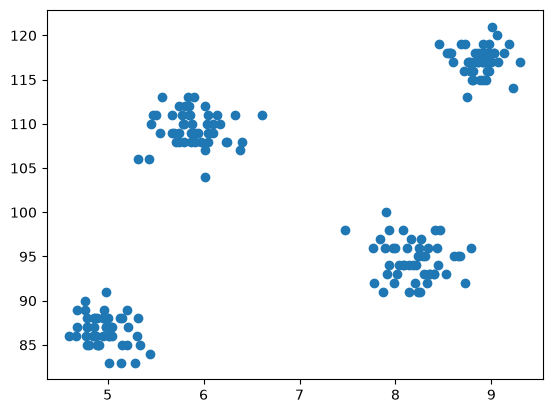

In [7]:
# matplotlib.pyplot
import matplotlib.pyplot as plt
plt.scatter(df['cgpa'], df['iq'])
# show plot
plt.show()

**Elbow Method**
- This is the method to find the value of K.

In [9]:
# import cluster Kmeans
from sklearn.cluster import KMeans

# append wcss value as cluster increases.
wcss = []

for i in range(1, 11):
    # create an object of kmeans
    km = KMeans(n_clusters=i)
    km.fit_predict(df)
    wcss.append(km.inertia_)

print(wcss)

[29957.898288, 4184.14127, 2364.0055834200834, 681.96966, 556.6603823704864, 457.43991159431914, 361.47851225944174, 266.44414787832284, 244.84081265312693, 177.00660502770498]


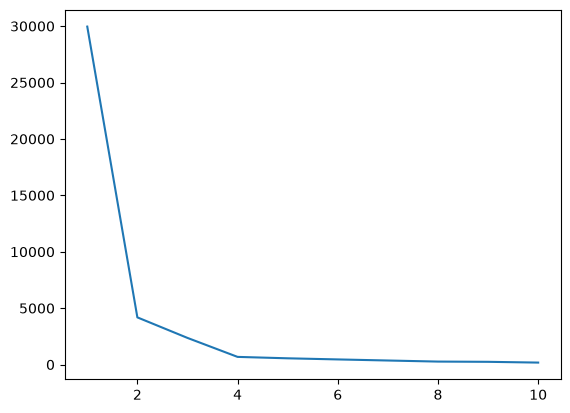

In [11]:
# Through could find K (Number of cluster would be) value. 
# plot the graph of wccs 
plt.plot(range(1, 11), wcss)
# show plot
plt.show()

In [18]:
# X a numpy array
X = df.iloc[:,:].values
# Create an KMeans Object
km = KMeans(n_clusters=4)
y_means = km.fit_predict(X)

# clusters
y_means

array([1, 0, 2, 2, 0, 0, 2, 3, 0, 2, 1, 0, 2, 1, 0, 2, 0, 2, 0, 0, 2, 1,
       2, 1, 1, 2, 1, 3, 2, 0, 3, 0, 3, 0, 2, 2, 3, 0, 1, 0, 1, 2, 2, 1,
       3, 3, 2, 0, 3, 0, 1, 1, 3, 2, 3, 0, 0, 3, 0, 3, 0, 2, 2, 3, 1, 3,
       2, 1, 0, 2, 0, 3, 2, 1, 0, 3, 0, 3, 1, 2, 2, 3, 0, 1, 3, 1, 3, 0,
       3, 0, 3, 3, 2, 1, 2, 2, 3, 2, 1, 3, 0, 1, 1, 3, 1, 1, 2, 1, 3, 3,
       2, 3, 0, 0, 2, 3, 2, 0, 3, 1, 1, 0, 2, 3, 2, 1, 2, 0, 1, 2, 2, 0,
       1, 1, 0, 3, 0, 1, 2, 2, 2, 1, 0, 1, 1, 3, 1, 3, 0, 1, 3, 1, 3, 3,
       1, 2, 0, 3, 0, 2, 1, 3, 0, 2, 3, 1, 0, 1, 1, 3, 3, 0, 3, 1, 1, 2,
       3, 0, 1, 3, 3, 0, 0, 0, 2, 1, 2, 2, 3, 0, 2, 2, 1, 1, 2, 1, 3, 0,
       0, 3], dtype=int32)

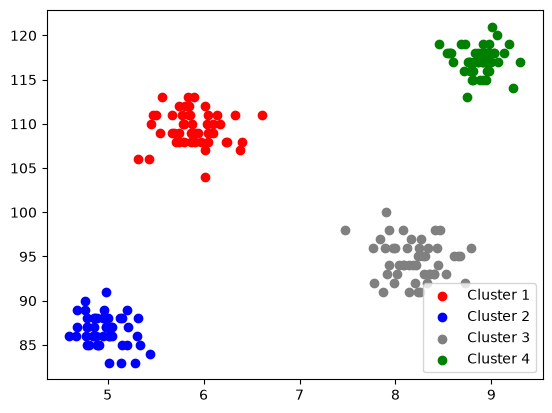

In [31]:

# ==============================================================================
# UNDERSTANDING NUMPY BOOLEAN MASKING / INDEXING
# ==============================================================================
# Formula: X[y_means == 0, 0]
# 
#  X        -> The main data table (rows and columns)
#  [ , ]    -> Split into [ROW_SELECTION , COLUMN_SELECTION]
#  
#  ROW_SELECTION    (y_means == 0) -> Checks a separate array 'y_means'.
#                                     Creates a list of True/False values.
#                                     Only rows marked 'True' are kept.
#
#  COLUMN_SELECTION (0)            -> Only extracts the 0th column (1st feature).
# ==============================================================================

# 1. Row Selection: Filter rows where the cluster label in 'y_means' is exactly 0
# 2. Column Selection: From those filtered rows, extract ONLY the 1st feature (column index 0)
x_coordinates_cluster_0 = X[y_means == 0, 0]

# 1. Row Selection: Filter rows where the cluster label in 'y_means' is exactly 0
# 2. Column Selection: From those filtered rows, extract ONLY the 2nd feature (column index 1)
y_coordinates_cluster_0 = X[y_means == 0, 1]


# ------------------------------------------------------------------------------
# HOW TO USE THIS FOR PLOTTING (COMMON MACHINE LEARNING USE CASE)
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt

# Plot Cluster 0 (Uses column 0 for X-axis, column 1 for Y-axis)
plt.scatter(
    X[y_means == 0, 0],  # X-axis: 1st feature of data in cluster 0
    X[y_means == 0, 1],  # Y-axis: 2nd feature of data in cluster 0
    c='red', 
    label='Cluster 1'
)

# Plot Cluster 1 (Uses column 0 for X-axis, column 1 for Y-axis)
plt.scatter(
    X[y_means == 1, 0],  # X-axis: 1st feature of data in cluster 1
    X[y_means == 1, 1],  # Y-axis: 2nd feature of data in cluster 1
    c='blue', 
    label='Cluster 2'
)

# Plot Cluster 2 (Uses column 0 for X-axis, column 1 for Y-axis)
plt.scatter(
    X[y_means == 2, 0],  # X-axis: 1st feature of data in cluster 1
    X[y_means == 2, 1],  # Y-axis: 2nd feature of data in cluster 1
    c='gray', 
    label='Cluster 3'
)

# Plot Cluster 3 (Uses column 0 for X-axis, column 1 for Y-axis)
plt.scatter(
    X[y_means == 3, 0],  # X-axis: 1st feature of data in cluster 1
    X[y_means == 3, 1],  # Y-axis: 2nd feature of data in cluster 1
    c='green', 
    label='Cluster 4'
)

# show legends
plt.legend()
# show plot
plt.show()


**K-Means 3-D Data**

In [32]:
from sklearn.datasets import make_blobs 

centroids = [(-5,-5,5),(5,5,-5), (3.5,-2.5,4), (-2.5,2.5,-4)]
cluster_std = [1,1,1,1]

X,y = make_blobs(
    n_samples= 200, 
    cluster_std= cluster_std, 
    centers=centroids, 
    n_features= 3, 
    random_state= 1
)

X

array([[ 4.33424548,  3.32580419, -4.17497018],
       [-3.32246719,  3.22171129, -4.625342  ],
       [-6.07296862, -4.13459237,  2.6984613 ],
       [ 6.90465871,  6.1110567 , -4.3409502 ],
       [-2.60839207,  2.95015551, -2.2346649 ],
       [ 5.88490881,  4.12271848, -5.86778722],
       [-4.68484061, -4.15383935,  4.14048406],
       [-1.82542929,  3.96089238, -3.4075272 ],
       [-5.34385368, -4.95640314,  4.37999916],
       [ 4.91549197,  4.70263812, -4.582698  ],
       [-3.80108212, -4.81484358,  4.62471505],
       [ 4.6735005 ,  3.65732421, -3.88561702],
       [-6.23005814, -4.4494625 ,  5.79280687],
       [-3.90232915,  2.95112294, -4.6949209 ],
       [ 3.72744124,  5.31354772, -4.49681519],
       [-3.3088472 ,  3.05743945, -3.81896126],
       [ 2.70273021, -2.21732429,  3.17390257],
       [ 4.06438286, -0.36217193,  3.214466  ],
       [ 4.69268607, -2.73794194,  5.15528789],
       [ 4.1210827 , -1.5438783 ,  3.29415949],
       [-6.61577235, -3.87858229,  5.408

In [35]:
# import plotly
import plotly.express as px
# 3D_scatter
fig = px.scatter_3d(x=X[:,0], y=X[:,1], z=X[:,2])

# show plot
fig.show()

In [41]:
# Empty list to append values of 
wcss_3d = []

for i in range(1, 21):
    # create an object 
    km = KMeans(n_clusters=i)
    # Fir the model
    km.fit(X)
    # Predict the model
    y_means = km.predict(X)
    # append into the empty list_.
    wcss_3d.append(km.inertia_)

wcss_3d

[11143.78432450336,
 4122.409557603533,
 2163.2694504362976,
 593.2516262404545,
 563.2997365534211,
 506.799095283293,
 452.4487604595001,
 468.1729168003586,
 405.66148431874325,
 393.75490148062323,
 351.11257229673095,
 351.6103102814624,
 317.02005817620267,
 294.5431360171796,
 283.9854323496098,
 257.3629545321046,
 245.49348302387827,
 247.33042985038992,
 226.5477874463551,
 237.63112616510276]

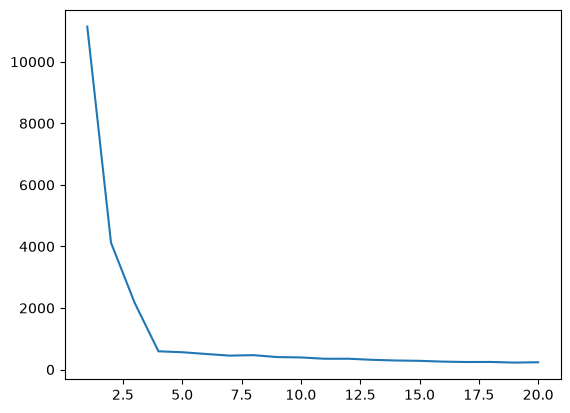

In [43]:
# plot elbow curve for the 3D.
plt.plot(range(1,21), wcss_3d)

**After Finding Elbow point: Again train KMeans model**

In [46]:
km = KMeans(n_clusters=4)
y_means = km.fit_predict(X)
y_means

array([2, 0, 1, 2, 0, 2, 1, 0, 1, 2, 1, 2, 1, 0, 2, 0, 3, 3, 3, 3, 1, 3,
       0, 1, 1, 2, 0, 3, 2, 0, 3, 2, 2, 1, 0, 2, 1, 0, 3, 3, 1, 0, 1, 2,
       0, 3, 3, 2, 0, 1, 2, 3, 3, 0, 1, 1, 0, 3, 3, 2, 1, 0, 0, 0, 3, 1,
       3, 2, 1, 0, 3, 2, 2, 2, 1, 2, 2, 2, 1, 3, 0, 1, 0, 0, 1, 0, 2, 1,
       1, 0, 2, 0, 0, 3, 0, 1, 1, 2, 1, 1, 2, 1, 1, 2, 0, 0, 0, 3, 3, 0,
       3, 2, 3, 0, 3, 0, 1, 0, 3, 2, 1, 2, 3, 3, 0, 1, 3, 2, 3, 1, 3, 1,
       0, 1, 2, 3, 3, 2, 0, 0, 1, 2, 2, 0, 1, 2, 2, 1, 0, 2, 0, 2, 3, 3,
       2, 3, 1, 0, 3, 2, 2, 1, 1, 3, 3, 1, 1, 3, 3, 1, 2, 1, 2, 3, 2, 2,
       0, 3, 3, 1, 0, 0, 3, 3, 3, 1, 0, 1, 2, 2, 0, 0, 2, 3, 3, 2, 0, 1,
       3, 0], dtype=int32)

In [ ]:
# Import plotly
import plotly.express as px

# Create a DataFrame
df = pd.DataFrame()
df['col1'] = X[:,0]
df['col2'] = X[:,1]
df['col3'] = X[:,2]
df['label'] = y_pred

# 3D_Scatter Plot
fig = px.scatter_3d(df, x='col1', y='col2', z='col3', color='label')

# show the plot
fig.show()